In [1]:
import sys; sys.path.append(r'/Users/siddharthmanikandan/Documents/Excalibur')
import os
import pickle
import logging
log = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO)
logging.getLogger("arviz").setLevel(logging.WARNING)
logging.getLogger("dawgie").setLevel(logging.CRITICAL)
logging.getLogger("pytensor").setLevel(logging.CRITICAL)
logging.getLogger("numexpr").setLevel(logging.WARNING)

import numpy as np
import matplotlib.pyplot as plt

import excalibur.system.core as syscore
import excalibur.cerberus.core as crbcore
import excalibur.cerberus.states as crbstt
import excalibur.cerberus.forward_model as crbfm

In [2]:
%matplotlib inline

In [3]:
# LOAD SV
cornichonpath = r'/Users/siddharthmanikandan/Documents/Excalibur-Pickles/'
fromdatabase = False
cleanupcornichons = False

target = 'TOI-260'
planet = 'b'
flt = 'JWST-NIRSPEC-NRS-F290LP-G395H'

name = ['system', 'Finalize', 'parameters']
rid = 1519  # LOOK IT UP THERE https://excalibur.jpl.nasa.gov/database/index.html INTERNAL ONLY
fullname = [target, str(rid)]
fullname.extend(name)
strname = '.'.join(fullname)
if cleanupcornichons:
    os.remove(cornichonpath + strname + '.pkl')
    pass
if os.path.isfile(cornichonpath + strname + '.pkl'):    
    with open(cornichonpath + strname + '.pkl', 'rb') as f:
        sysfin = pickle.load(f)
        pass
    pass
else:
    sysfin = loadSV(name, target, rid)
    with open(cornichonpath + strname + '.pkl', 'wb') as f:
        logging.info('>-- PICKLING %s', strname)
        pickle.dump(sysfin, f, pickle.HIGHEST_PROTOCOL)
        pass
    pass

name = ['transit', 'Spectrum', flt]
rid = 1565
fullname = [target, str(rid)]
fullname.extend(name)
strname = '.'.join(fullname)
if cleanupcornichons:
    os.remove(cornichonpath + strname + '.pkl')
    pass
if os.path.isfile(cornichonpath + strname + '.pkl'):    
    with open(cornichonpath + strname + '.pkl', 'rb') as f:
        trnspc = pickle.load(f)
        pass
    pass
else:
    trnspc = loadSV(name, target, rid)
    with open(cornichonpath + strname + '.pkl', 'wb') as f:
        logging.info('>-- PICKLING %s', strname)
        pickle.dump(trnspc, f, pickle.HIGHEST_PROTOCOL)
        pass
    pass
spc = {}
spc['data'] = {}
spc['data'][planet] = {}
spc['data'][planet]['WB'] = np.concatenate([trnspc['data'][planet][det]['1']['WB'] for det in ['NRS1', 'NRS2']])
rtp = crbcore.CerbXSlibParams(
    knownspecies=['NO', 'OH', 'C2H2', 'N2', 'N2O', 'O3', 'O2'],
    cialist=['H2-H', 'H2-H2', 'H2-He', 'He-H'],
    xmollist=['TIO', 'H2O', 'H2CO', 'HCN', 'CO', 'CO2', 'NH3', 'CH4','C2H2', 'C2H6', 'C3H8', 'CH3CHO', 'SO2','H2S'],
    nlevels=100,
    solrad=10,
    Hsmax=25,
    lbroadening=False,
    lshifting=False,
)

name = ['cerberus', 'XSLib', flt]
rid = 6666
fullname = [target, str(rid)]
fullname.extend(name)
strname = '.'.join(fullname)
if cleanupcornichons:
    os.remove(cornichonpath + strname + '.pkl')
    pass
if os.path.isfile(cornichonpath + strname + '.pkl'):    
    with open(cornichonpath + strname + '.pkl', 'rb') as f:
        crbxsl = pickle.load(f)
        pass
    pass
else:
    crbxsl = crbstt.XslibSv(flt)
    _ = crbcore.myxsecs(
        spc, rtp, crbxsl,
        only_these_planets=[planet], verbose=False,
    )
    with open(cornichonpath + strname + '.pkl', 'wb') as f:
        logging.info('>-- PICKLING %s', strname)
        pickle.dump(crbxsl, f, pickle.HIGHEST_PROTOCOL)
        pass
    pass

/Users/siddharthmanikandan/Documents/Excalibur/.venv312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


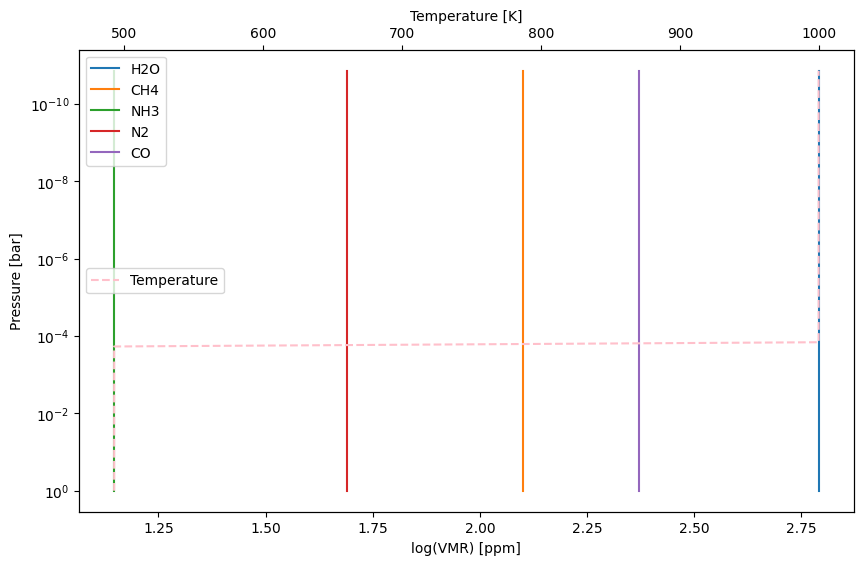

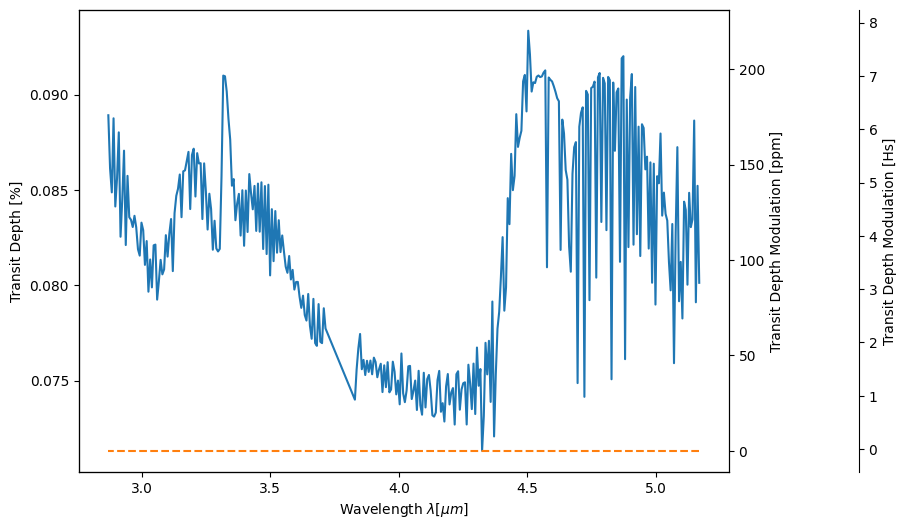

In [4]:
# --< PLOTS >--
# ENABLE ZHANG, WEST et al. 2014 HAZE DENSITY PROFILE PLOTS IF SET TO 'True'
jptplot = False
# ENABLE FORWARD MODEL PLOT IF SET TO 'True'
verbose = True

# --< CERBERUS FORWARD MODEL >--
# LOAD UNIT CONVERSION AND CONSTANTS UTILITY
ssc = syscore.ssconstants(mks=True)

# --< GAS MODEL: 'TEC' or 'FREE' >--
model = 'TEC'
# THERMAL EQUILIBRUM CHEMISTRY (TEC), CONSTANT VOLUME MIXING RATIO APPROXIMATION
# CtoO: log10(scaling factor) TO SOLAR CARBON TO OXYGEN RATIO, 0 EQUIVALENT TO 1 TIMES SOLAR
# XtoH: log10(scaling factor) TO SOLAR 'METALLICITY' (MOLECULES HEAVIER THAN H2), 0 EQUIVALENT TO 1 TIMES SOLAR
# REMAINING OF THE ATMOSPHERE IS FILLED WITH H/H2 IN SOLAR RELATIVE ABUNDANCES
# H2 ABSORPTION = 0, SCATTERING CROSS SECTION FOLLOWS Naus & Ubachs, 2000
if model == 'TEC':
    mixratio = None
    tceqdict = {}
    tceqdict['CtoO'] = 0
    tceqdict['XtoH'] = 0
    tceqdict['NtoO'] = 0    
    pass
# FREE CHEMISTRY (FREE), CONSTANT VOLUME MIXING RATIO APPROXIMATION
# VOLUME MIXING RATIOS ARE EXPRESSED IN LOG10(VMR) IN PARTS PER MILLION (ppm), 
# -6 EQUIVALENT TO NOT EXISTENT, 0 EQUIVALENT TO 1ppm, 2 EQUIVALENT TO 100ppm
# REMAINING OF THE ATMOSPHERE IS FILLED WITH H/H2 IN SOLAR RELATIVE ABUNDANCES
# H2 ABSORPTION = 0, SCATTERING CROSS SECTION FOLLOWS Naus & Ubachs, 2000
# IF ALL GAS ABSORBERS ARE SET TO -6, MODEL WILL SHOW CIA ['H2-H', 'H2-H2', 'H2-He', 'He-H']
if model == 'FREE':
    noabs = -10
    mixratio = {}
    #mixratio['TIO'] = noabs
    mixratio['C2H2'] = np.ones(100) * 5.0  # Put the full VMR profile in there in log10 ppm
    mixratio['H2O'] = 2
    #mixratio['H2CO'] = noabs
    #mixratio['HCN'] = noabs
    #mixratio['CO'] = noabs
    #mixratio['CO2'] = noabs
    mixratio['NH3'] = noabs
    #mixratio['NO'] = noabs
    #mixratio['OH'] = noabs
    #mixratio['C2H2'] = noabs
    #mixratio['N2'] = noabs
    #mixratio['N2O'] = noabs
    #mixratio['O3'] = noabs
    #mixratio['O2'] = noabs
    tceqdict = None
    pass

model = 'FREE'

# --< ISOTHERMAL APPROXIMATION (K) >--
# EQUILIBRIUM TEMPERATURE ESTIMATE FROM ORBITAL SOLUTION
Tfact = np.sqrt(sysfin['priors']['R*']*ssc['Rsun/AU']/(2.*sysfin['priors'][planet]['sma']))
Tav = float(sysfin['priors']['T*']*Tfact)
Tav = np.asarray([Tav] * 100, dtype=float)
pgrid = np.arange(np.log(1) - 20, np.log(1) + 20 / 100, 20 / (100 - 1),)
pgrid = np.exp(pgrid)
pressure = pgrid[::-1]
Tav[pressure < 10**-3] = 1000

#mixratio['C2H2'][pressure > 10**-3] = -6

# ALTERNATIVELY TEMPERATURE Tav IN KELVIN [K] CAN BE MANUALLY SET UP HERE TO AN ARBITRARY VALUE INSTEAD OF Teq
#Tav = sysfin['priors']['T*']*Tfact

# --< AEROSOL >--
# AEROSOL MODEL DENSITY PROFILE: 'H2SCALE' or 'JUPITER'
aeromodel = 'JUPITER'
# H2SCALE 
# haze: LOG10(SCALING FACTOR) TO H2 SCATTERING CROSS SECTION, NO ABSORPTION
# -6 EQUIVALENT TO NO HAZE, 0 EQUIVALENT TO 1 TIMES H2 SCATTERING CROSS SECTION
if aeromodel == 'H2SCALE':
    haze = None
    hzlib = None
    hzp = None
    hztop = None
    pass
# JUPITER
# haze: LOG10(SCALING FACTOR) TO JUPITER OBSERVED SCATTERING CROSS SECTION, NO ABSORPTION
# -6 EQUIVALENT TO NO HAZE, 0 EQUIVALENT TO 1 TIMES JUPITER SCATTERING CROSS SECTION, West et al, 2004
# DENSITY PROFILE TAKEN FROM CASSINI ISS OBSERVATION Zhang, West et al, 2014
if aeromodel == 'JUPITER':
    haze = -10
    # LOAD CASSINI ISS DATA
    crbhzlib = {'PROFILE':[]}
    crbcore.hazelib(crbhzlib, hazedir='/Users/siddharthmanikandan/Documents/Excalibur-Pickles/', verbose=False)  # CHANGE THAT TO YOUR PICKLE DIR
    # DENSITY PROFILE MODEL ('CONSTANT', 'MAX', 'MEDIAN' OR 'AVERAGE' ACROSS LATITUDES)
    hzp = 'AVERAGE'
    # MOVES THE AEROSOL CLOUD DENSITY PROFILE IN PRESSURE LOG10 SPACE UP AND DOWN RELATIVE TO JUPITER PROFILE
    # AND SET THE MAX DENSITY AT 10^hztop BARS, DEFAULT VALUE SET TO JUPITER BY hztop = -1.7
    hztop = -3.43
    # SCATTERING CROSS SECTION POWER LAW INDEX VS WAVELENGTH
    hzslope = -4
    hzwscale = 3.1
    pass

# --< SEMI FINITE BOTTOM CLOUD >--
# ctp: LOG10(CLOUD TOP PRESSURE) [bar], OPAQUE BELOW CTP PRESSURE LEVEL
# 1 EQUIVALENT TO NO CLOUD SINCE CLOUD TOP IS AT THE SOLID RADIUS PRESSURE LEVEL (10 BARS)
ctp = 1

# --< FORWARD MODEL CALL >--
# SOLID/OPAQUE RADIUS (10 BAR PRESSURE LEVEL) ESTIMATE
solidr = sysfin['priors'][planet]['rp']*ssc['Rjup'] # MKS

# SPHERICAL SHELL FMC IS AN ARRAY (MODEL) AS A FUNCTION OF wgrid (WAVELENGTH)
fmc = crbfm.crbFM().crbmodel(
    Tav, ctp, 
    cheq=tceqdict,
    mixratio=mixratio,
    hazescale=haze,
    hazethick=hzwscale,
    hazeloc=hztop,
    hazeprof=hzp,
    hzlib=crbhzlib,
    planet=planet,
    rp0=solidr,
    orbp=sysfin['priors'],
    wgrid=spc['data'][planet]['WB'],
    xsecs=crbxsl['data'][planet]['XSECS'],
    qtgrid=crbxsl['data'][planet]['QTGRID'],
    cialist=rtp.cialist,
    xmollist=rtp.xmollist,
    nlevels=100,
    Hsmax=25,
    solrad=1,
    break_down_by_molecule=True,
    logx=False,
    verbose=True,
    debug=False
)

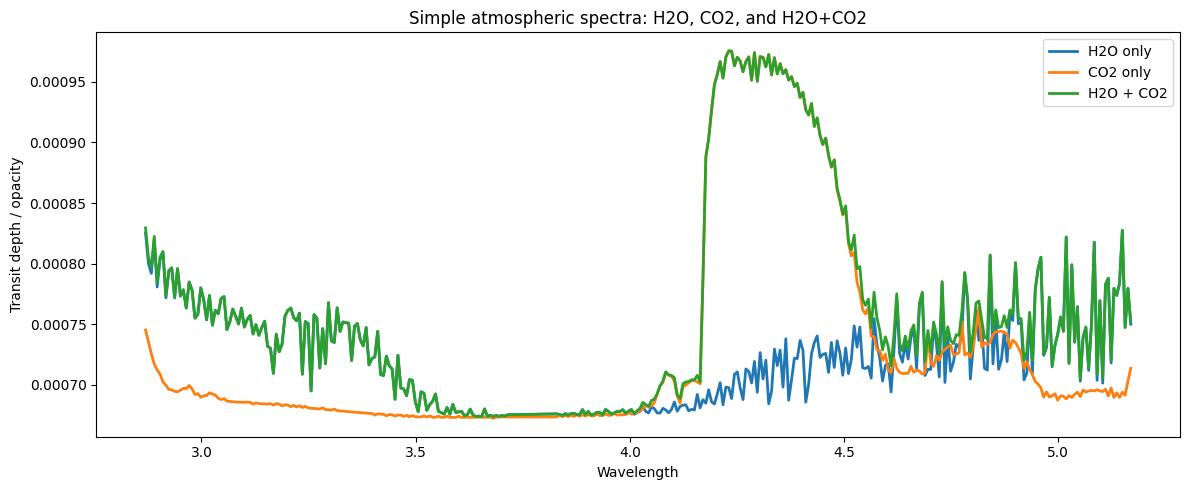

H2O mixratio: {'H2O': array([2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.]), 'CO2': array([-10., -10., -10., -10., -10., -10., -10., -10., -10., -10., -10.,
       -10., -10., -10., -10., -10., -10., -10., -10., -10., -10., -10.,
       -10., -10., -10., -10., -10., -10., -10., -10., -10., -10., -10.,
       -10., -10., -10., -10., -10., -10., -10., -10., -10., -10., -10.,
       -10., -10., -10., -10., -10., -10., -10., -10., -10., -10., -10.,
       -10., -10., -10., -10., -10., -10., -10., -10., -10., -10., -10.,
       -10., -10., -10., -10., -10., -10., -10., -10., -10., -10., -10.,
       -10., -10

In [5]:
# --- SIMPLE STARTER: H2O, CO2, and H2O+CO2 spectra ---
# This is the cleanest starting workflow for your goal.
# Values are log10(ppm): -10 = off / effectively zero, 2 = 100 ppm, 4 = 10,000 ppm.
noabs = -10
species = ['H2O', 'CO2', 'CH4', 'CO', 'HCN', 'C2H2', 'NH3', 'SO2', 'H2S']


def make_mixratio(active=None, value=2.0):
    mix = {mol: noabs for mol in species}
    if active is not None:
        mix[active] = value
    return mix


mixratio_h2o = make_mixratio('H2O', 2.0)
mixratio_co2 = make_mixratio('CO2', 2.0)
mixratio_h2o_co2 = {
    'H2O': 2.0,
    'CO2': 2.0,
    'CH4': noabs,
    'CO': noabs,
    'HCN': noabs,
    'C2H2': noabs,
    'NH3': noabs,
    'SO2': noabs,
    'H2S': noabs,
}

# Run model for H2O only
fmc_h2o = crbfm.crbFM().crbmodel(
    Tav, ctp,
    cheq=tceqdict,
    mixratio=mixratio_h2o,
    hazescale=haze,
    hazethick=hzwscale,
    hazeloc=hztop,
    hazeprof=hzp,
    hzlib=crbhzlib,
    planet=planet,
    rp0=solidr,
    orbp=sysfin['priors'],
    wgrid=spc['data'][planet]['WB'],
    xsecs=crbxsl['data'][planet]['XSECS'],
    qtgrid=crbxsl['data'][planet]['QTGRID'],
    cialist=rtp.cialist,
    xmollist=rtp.xmollist,
    nlevels=100,
    Hsmax=25,
    solrad=1,
    break_down_by_molecule=True,
    logx=False,
    verbose=False,
    debug=False,
)

# Run model for CO2 only
fmc_co2 = crbfm.crbFM().crbmodel(
    Tav, ctp,
    cheq=tceqdict,
    mixratio=mixratio_co2,
    hazescale=haze,
    hazethick=hzwscale,
    hazeloc=hztop,
    hazeprof=hzp,
    hzlib=crbhzlib,
    planet=planet,
    rp0=solidr,
    orbp=sysfin['priors'],
    wgrid=spc['data'][planet]['WB'],
    xsecs=crbxsl['data'][planet]['XSECS'],
    qtgrid=crbxsl['data'][planet]['QTGRID'],
    cialist=rtp.cialist,
    xmollist=rtp.xmollist,
    nlevels=100,
    Hsmax=25,
    solrad=1,
    break_down_by_molecule=True,
    logx=False,
    verbose=False,
    debug=False,
)

# Run model for H2O + CO2 together
fmc_h2o_co2 = crbfm.crbFM().crbmodel(
    Tav, ctp,
    cheq=tceqdict,
    mixratio=mixratio_h2o_co2,
    hazescale=haze,
    hazethick=hzwscale,
    hazeloc=hztop,
    hazeprof=hzp,
    hzlib=crbhzlib,
    planet=planet,
    rp0=solidr,
    orbp=sysfin['priors'],
    wgrid=spc['data'][planet]['WB'],
    xsecs=crbxsl['data'][planet]['XSECS'],
    qtgrid=crbxsl['data'][planet]['QTGRID'],
    cialist=rtp.cialist,
    xmollist=rtp.xmollist,
    nlevels=100,
    Hsmax=25,
    solrad=1,
    break_down_by_molecule=True,
    logx=False,
    verbose=False,
    debug=False,
)

# Plot comparison
plt.figure(figsize=(12, 5))
plt.plot(spc['data'][planet]['WB'], fmc_h2o['spectrum'], label='H2O only', linewidth=2)
plt.plot(spc['data'][planet]['WB'], fmc_co2['spectrum'], label='CO2 only', linewidth=2)
plt.plot(spc['data'][planet]['WB'], fmc_h2o_co2['spectrum'], label='H2O + CO2', linewidth=2)
plt.xlabel('Wavelength')
plt.ylabel('Transit depth / opacity')
plt.title('Simple atmospheric spectra: H2O, CO2, and H2O+CO2')
plt.legend()
plt.tight_layout()
plt.show()

print('H2O mixratio:', mixratio_h2o)
print('CO2 mixratio:', mixratio_co2)
print('H2O+CO2 mixratio:', mixratio_h2o_co2)


# saved outputs
#
# - abundance_ranker_dataset.npz
# - abundance_ranker_model.joblib
# - abundance_ranker_metrics.json
# - abundance_ranker_topk.json
# - abundance_ranker_dataset.json

In [6]:
import json
from pathlib import Path
import numpy as np
import joblib

root = Path('/Users/siddharthmanikandan/Documents/Excalibur')
model_path = root / 'datasets' / 'abundance_ranker_model.joblib'
dataset_path = root / 'datasets' / 'abundance_ranker_dataset.npz'
metrics_path = root / 'datasets' / 'abundance_ranker_metrics.json'

model = joblib.load(model_path)
with np.load(dataset_path) as data:
    species = data['species']
    sample_spectrum = data['spectra'][0]
    sample_labels = data['labels'][0]

with open(metrics_path, 'r', encoding='utf-8') as f:
    metrics = json.load(f)

pred = model.predict(sample_spectrum.reshape(1, -1))[0]
rank_order = np.argsort(pred)[::-1]
print('Species list:', species)
print('Sample true abundances (log10 ppm):', sample_labels)
print('Predicted abundances (log10 ppm):', np.round(pred, 3))
print('Top ranked molecules:', [species[i] for i in rank_order[:5]])
print('Top ranked values:', np.round(pred[rank_order[:5]], 3))
print('Model quality (R2):', metrics['r2_by_species'])

Species list: ['H2O' 'CO2' 'CH4' 'CO' 'NH3' 'HCN' 'C2H2']
Sample true abundances (log10 ppm): [ 1.34411851 -2.72983565 -1.48238572 -8.93082552  0.39438547  1.76972843
  1.98548326]
Predicted abundances (log10 ppm): [ 0.594 -3.585 -1.848 -6.753  0.08   1.198  1.021]
Top ranked molecules: [np.str_('HCN'), np.str_('C2H2'), np.str_('H2O'), np.str_('NH3'), np.str_('CH4')]
Top ranked values: [ 1.198  1.021  0.594  0.08  -1.848]
Model quality (R2): {'H2O': 0.3214477684863931, 'CO2': 0.8696954318003296, 'CH4': 0.6311099059783023, 'CO': 0.6714221846556538, 'NH3': 0.34761367013971234, 'HCN': 0.31173399691152903, 'C2H2': -0.10535007450190692}


Top predictions for the generated spectrum:
  H2O -> 0.914 log10 ppm
  CO2 -> 0.849 log10 ppm
  C2H2 -> -2.348 log10 ppm
  NH3 -> -3.774 log10 ppm
  CO -> -3.786 log10 ppm


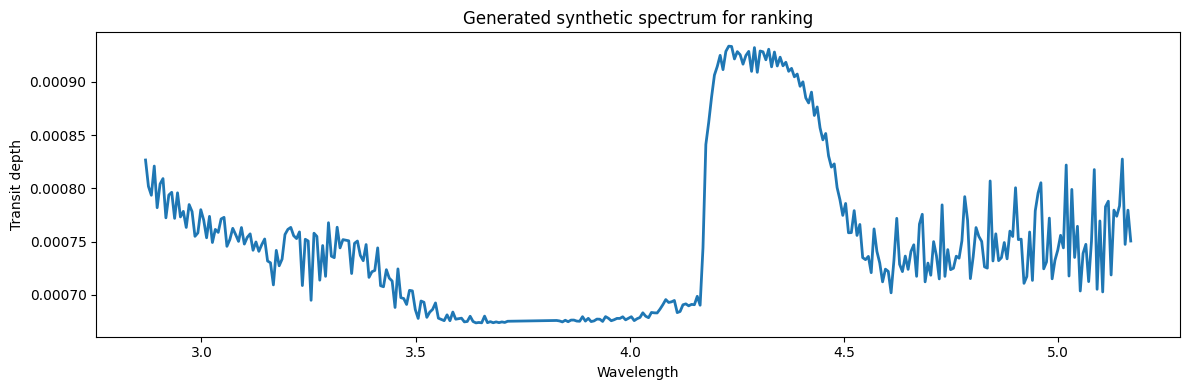

In [8]:
import json
from pathlib import Path
import pickle
import numpy as np
import joblib

root = Path('/Users/siddharthmanikandan/Documents/Excalibur')
model = joblib.load(root / 'datasets' / 'abundance_ranker_model.joblib')
with np.load(root / 'datasets' / 'abundance_ranker_dataset.npz') as data:
    species = data['species']
    wavelength = data['wavelengths']

mix = {mol: -10.0 for mol in species}
mix['H2O'] = 2.0
mix['CO2'] = 1.5
mix['CH4'] = -4.0
mix['CO'] = -5.0
mix['NH3'] = -6.0
mix['HCN'] = -7.0
mix['C2H2'] = -8.0

cornichonpath = r'/Users/siddharthmanikandan/Documents/Excalibur-Pickles/'
name = ['system', 'Finalize', 'parameters']
with open(cornichonpath + 'TOI-260.1519.system.Finalize.parameters.pkl', 'rb') as f:
    sysfin = pickle.load(f)

name = ['transit', 'Spectrum', 'JWST-NIRSPEC-NRS-F290LP-G395H']
with open(cornichonpath + 'TOI-260.1565.transit.Spectrum.JWST-NIRSPEC-NRS-F290LP-G395H.pkl', 'rb') as f:
    trnspc = pickle.load(f)

spc = {'data': {'b': {'WB': np.concatenate([trnspc['data']['b'][det]['1']['WB'] for det in ['NRS1', 'NRS2']])}}}

rtp = crbcore.CerbXSlibParams(
    knownspecies=['NO', 'OH', 'C2H2', 'N2', 'N2O', 'O3', 'O2'],
    cialist=['H2-H', 'H2-H2', 'H2-He', 'He-H'],
    xmollist=['TIO', 'H2O', 'H2CO', 'HCN', 'CO', 'CO2', 'NH3', 'CH4', 'C2H2', 'C2H6', 'C3H8', 'CH3CHO', 'SO2', 'H2S'],
    nlevels=100,
    solrad=10,
    Hsmax=25,
    lbroadening=False,
    lshifting=False,
)

with open(cornichonpath + 'TOI-260.6666.cerberus.XSLib.JWST-NIRSPEC-NRS-F290LP-G395H.pkl', 'rb') as f:
    crbxsl = pickle.load(f)

ssc = syscore.ssconstants(mks=True)
Tfact = np.sqrt(sysfin['priors']['R*'] * ssc['Rsun/AU'] / (2.0 * sysfin['priors']['b']['sma']))
Tav = np.asarray([float(sysfin['priors']['T*'] * Tfact)] * 100, dtype=float)
press = np.exp(np.arange(np.log(1) - 20, np.log(1) + 20 / 100, 20 / (100 - 1))[::-1])
Tav[press < 10 ** -3] = 1000

crbhzlib = {'PROFILE': []}
crbcore.hazelib(crbhzlib, hazedir=cornichonpath, verbose=False)

spec = crbfm.crbFM().crbmodel(
    Tav, 1,
    cheq=None,
    mixratio=mix,
    hazescale=-10,
    hazethick=3.1,
    hazeloc=-3.43,
    hazeprof='AVERAGE',
    hzlib=crbhzlib,
    planet='b',
    rp0=sysfin['priors']['b']['rp'] * ssc['Rjup'],
    orbp=sysfin['priors'],
    wgrid=spc['data']['b']['WB'],
    xsecs=crbxsl['data']['b']['XSECS'],
    qtgrid=crbxsl['data']['b']['QTGRID'],
    cialist=rtp.cialist,
    xmollist=rtp.xmollist,
    nlevels=100,
    Hsmax=25,
    solrad=1,
    break_down_by_molecule=True,
    logx=False,
    verbose=False,
    debug=False,
)['spectrum']

pred = model.predict(np.asarray(spec).reshape(1, -1))[0]
order = np.argsort(pred)[::-1]
print('Top predictions for the generated spectrum:')
for idx in order[:5]:
    print(f'  {species[idx]} -> {pred[idx]:.3f} log10 ppm')

plt.figure(figsize=(12, 4))
plt.plot(spc['data']['b']['WB'], spec, linewidth=2)
plt.xlabel('Wavelength')
plt.ylabel('Transit depth')
plt.title('Generated synthetic spectrum for ranking')
plt.tight_layout()
plt.show()

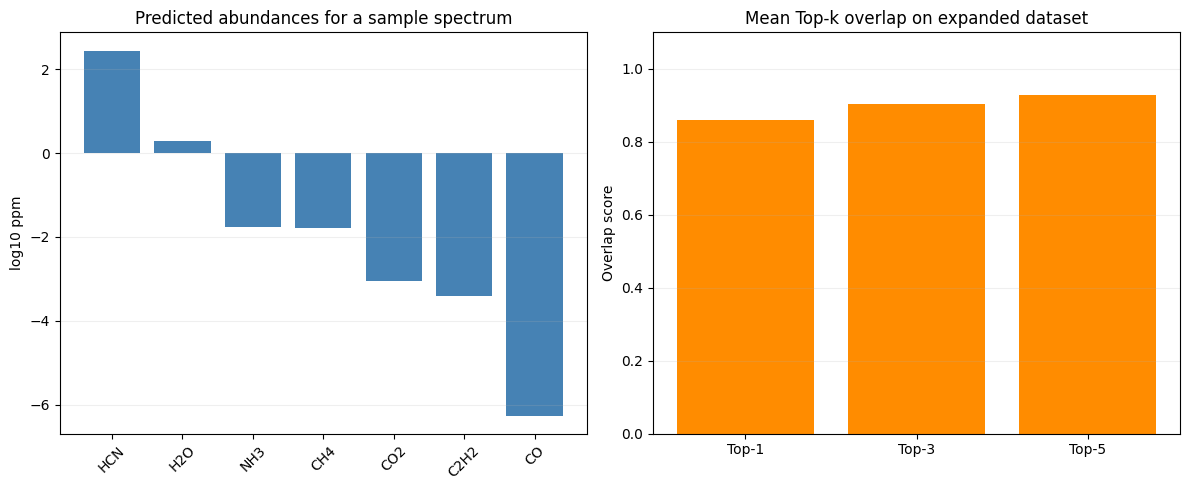

Visual validation saved to the datasets folder.
Top-1 overlap: 0.859
Top-3 overlap: 0.904
Top-5 overlap: 0.928
Top predicted species for sample: [np.str_('HCN'), np.str_('H2O'), np.str_('NH3'), np.str_('CH4'), np.str_('CO2')]


In [ ]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import joblib

root = Path('/Users/siddharthmanikandan/Documents/Excalibur')
model = joblib.load(root / 'datasets' / 'abundance_ranker_model.joblib')
with np.load(root / 'datasets' / 'abundance_ranker_dataset.npz') as data:
    species = data['species']
    spectra = data['spectra']
    labels = data['labels']

pred = model.predict(spectra)
ks = [1, 3, 5]
mean_overlaps = []
for k in ks:
    overlaps = []
    for true_row, pred_row in zip(labels, pred):
        true_top = np.argsort(true_row)[::-1][:k]
        pred_top = np.argsort(pred_row)[::-1][:k]
        overlaps.append(len(set(true_top) & set(pred_top)) / k)
    mean_overlaps.append(np.mean(overlaps))

sample_idx = 0
sample_true = labels[sample_idx]
sample_pred = pred[sample_idx]
order = np.argsort(sample_pred)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar([species[i] for i in order[:7]], sample_pred[order[:7]], color='steelblue')
axes[0].set_title('Predicted abundances for a sample spectrum')
axes[0].set_ylabel('log10 ppm')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar([f'Top-{k}' for k in ks], mean_overlaps, color='darkorange')
axes[1].set_title('Mean Top-k overlap on expanded dataset')
axes[1].set_ylabel('Overlap score')
axes[1].set_ylim(0, 1.1)

for ax in axes:
    ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig(root / 'datasets' / 'abundance_ranker_visual_validation.png', dpi=200)
plt.show()

print('Top-1 overlap:', round(mean_overlaps[0], 3))
print('Top-3 overlap:', round(mean_overlaps[1], 3))
print('Top-5 overlap:', round(mean_overlaps[2], 3))
print('Top predicted species for sample:', [species[i] for i in order[:5]])